In [1]:
# Gõ dòng này vào cell đầu tiên và bấm Run (Shift + Enter) or Run All
get_ipython().run_line_magic('run', '../_setup.py')

In [2]:
from functools import partial, reduce

import statsmodels.api as sm
from matplotlib.ticker import MaxNLocator
from prophet import Prophet
from statsforecast import StatsForecast
from statsforecast.adapters.prophet import AutoARIMAProphet
from statsforecast.models import MSTL, AutoETS, AutoARIMA, ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.api import VAR
from utilsforecast.evaluation import evaluate
from utilsforecast.feature_engineering import trend, fourier, pipeline
from utilsforecast.losses import rmse, mae, mape, mase
from utilsforecast.preprocessing import fill_gaps

Importing plotly failed. Interactive plots will not work.


In [3]:
BASE_DIR = Path.cwd().parent.parent
DATA_DIR = BASE_DIR / "data"
print(DATA_DIR)

/home/phu/Documents/GitHub/-Time-Series-Analysis-and-Forecasting-methods-/data


# Advanced forecasting methods 

In this chapter, we briefly discuss four more advanced forecasting methods that build on the models discussed in earlier chapters.

## 12.1 Complex seasonality

So far, we have mostly considered relatively simple seasonal patterns such as quarterly and monthly data. However, higher frequency time series often exhibit more complicated seasonal patterns. For example, daily data may have a weekly pattern as well as an annual pattern. Hourly data usually has three types of seasonality: a daily pattern, a weekly pattern, and an annual pattern. Even weekly data can be challenging to forecast as there are not a whole number of weeks in a year, so the annual pattern has a seasonal period of $365.25/7 \approx 52.179$ on average. 



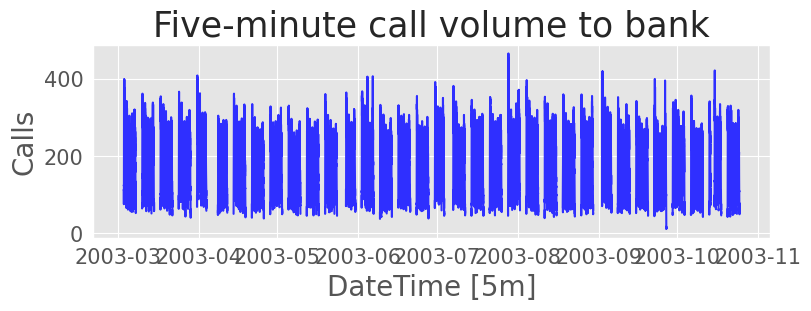

In [4]:
bank_calls = (
    pd.read_csv(DATA_DIR / "bank_calls.csv", parse_dates=["ds"])
    .loc[lambda x: x["y"] > 0]
)
bank_calls_5min = fill_gaps(bank_calls, freq="5min")
fig, ax = plt.subplots(figsize=(8, 3))
plot_series(
    bank_calls_5min,
    xlabel="DateTime [5m]", ylabel="Calls",
    title="Five-minute call volume to bank",
    ax=ax,
)

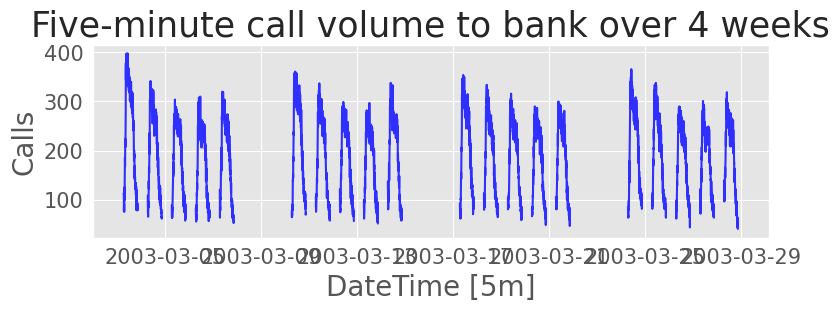

In [5]:
df = bank_calls_5min.loc[lambda x: x["ds"] <= "2003-03-29"]
fig, ax = plt.subplots(figsize=(8, 3))
plot_series(df, xlabel="DateTime [5m]", ylabel="Calls",
    title="Five-minute call volume to bank over 4 weeks",
    ax=ax,
)

### MSTL with multiple seasonal periods 

The `MSTL()` function is designed to deal with multiple seasonalities, and it can be used to decompose a series into its trend, multiple seasonal, and remainder components.

In [6]:
model = MSTL(season_length=[169, 169 * 5])
sf = StatsForecast(models=[model], freq="5min")
sf = sf.fit(bank_calls.assign(y = lambda df: np.sqrt(df["y"])))
dcmp = sf.fitted_[0, 0].model_

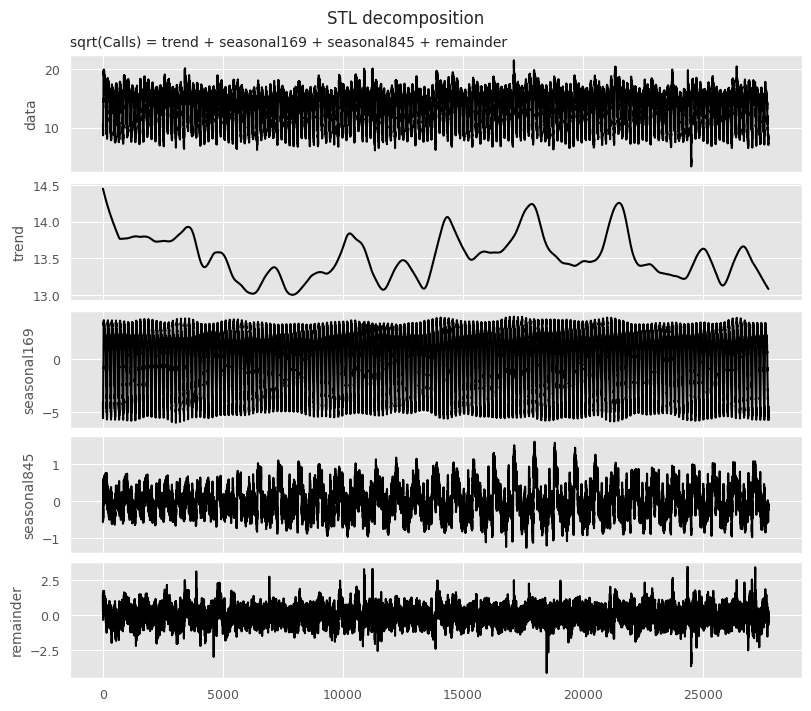

In [7]:
fig, axes = plt.subplots(5, figsize=(8, 7), sharex=True)
for (ax, column) in zip(axes, dcmp.columns):
    sns.lineplot(data=dcmp, x=dcmp.index, y=column, ax=ax, color="k")
axes[0].set_title(
    "sqrt(Calls) = trend + seasonal169 + seasonal845 + remainder",
    size="medium", loc="left")
axes[-1].set(xlabel="")
fig.suptitle("STL decomposition")
plt.show()

There are two seasonal patterns shown in Figure 12.3, one for the time of day (the third panel), and one for the time of week (the fourth panel). Note that in this case, there is little trend seen in the data, and the weekly seasonality is weak.

The decomposition can also be used in forecasting, with each of the seasonal components forecast using a `Seasonal Naïve` method, and the seasonally adjusted data forecast using `ETS`.

In [8]:
# Find forecast timestamps: weekdays 7am to 9pm
start = bank_calls["ds"].max() + pd.offsets.Minute(5)
all_5min = pd.date_range(start, start + pd.offsets.Day(7), freq="5min")
fc_ds = all_5min.to_series().loc[lambda x: (
    x.dt.weekday.between(0, 4)
    & x.dt.strftime("%H:%M").between("07:00", "21:00")
)]

# Forecast, back-transform numerical results, and set ds with gaps
fc = sf.predict(h=len(fc_ds), level=[80, 95])
res = fc.select_dtypes(include=np.number)
fc = (
    fc.assign(**res.transform(lambda x: x**2))
    .assign(ds=fc_ds.to_numpy())
    .pipe(fill_gaps, freq="5min")
)

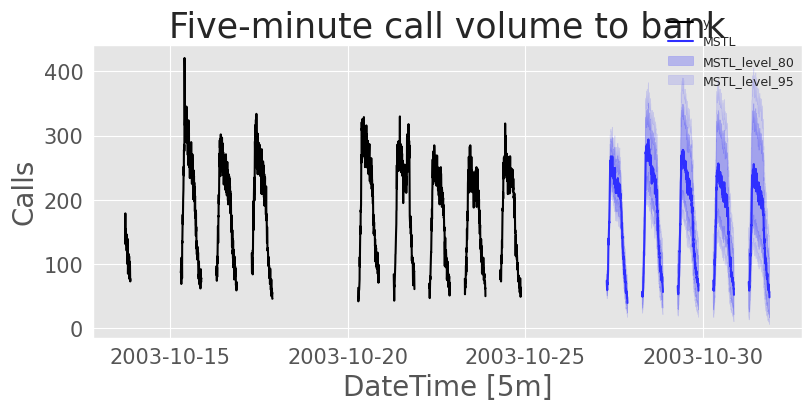

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_series(bank_calls_5min, fc, level=[80, 95],
    max_insample_length=169 * (14 + 5),
    xlabel="DateTime [5m]", ylabel="Calls",
    title="Five-minute call volume to bank",
    palette="black_and_blue", rm_legend=False, ax=ax)
ax.xaxis.set_major_locator(MaxNLocator(4))
fig

### Dynamic harmonic regression with multiple seasonal periods

When a time series exhibits multiple seasonalities, Fourier terms (sine and cosine waves) can be introduced for each seasonal period to capture the cycles .
* Structure: A DHR model is paired with an ARIMA error structure to handle residual autocorrelation . For example, if a dataset has daily (period 169) and weekly (period 845) cycles, the Fourier terms take the form :$$\sin\left(\frac{2\pi kt}{169}\right), \quad \cos\left(\frac{2\pi kt}{169}\right), \quad \sin\left(\frac{2\pi kt}{845}\right), \quad \cos\left(\frac{2\pi kt}{845}\right)$$
* Parameter Selection: While the Akaike Information Criterion corrected ($AICc$) can theoretically select the number of Fourier terms, it tends to over-estimate them for high seasonal periods . Therefore, subjective choices (e.g., 10 terms for daily, 5 terms for weekly) are often preferred . Non-stationarity and seasonality are handled entirely through the regression terms by setting $D=d=0$ and $P=Q=0$ in AutoARIMA(seasonal=False) .
* Predictor Challenges: Forecasting with DHR can be difficult because it requires future values of external predictors (like temperature forecasts for electricity demand modeling) . Forecasters often rely on scenario forecasting or meteorological models to fill in these future values .

In [10]:
# features = [
#     partial(fourier, season_length=169, k=10),
#     partial(fourier, season_length=5 * 169, k=5),
# ]
# bank_calls_fourier, bank_calls_futr_fourier = pipeline(
#     bank_calls, features=features, freq="5min", h=len(fc_ds))

# # Remove redundant Fourier features
# dropcols = ["sin5_845", "cos5_845"]
# bank_calls_fourier = bank_calls_fourier.drop(columns=dropcols)
# bank_calls_futr_fourier = bank_calls_futr_fourier.drop(columns=dropcols)

# model = AutoARIMA(d=0, seasonal=False, nmodels=5)
# sf = StatsForecast(models=[model], freq="5min")
# sf = sf.fit(bank_calls_fourier)

# level = [80, 95]
# fc_fourier = (
#     sf.predict(h=len(fc_ds), X_df=bank_calls_futr_fourier, level=level)
#     .assign(ds=fc_ds.to_numpy())
#     .pipe(fill_gaps, freq="5min")
# )

# fig, ax = plt.subplots(figsize=(8, 4))
# plot_series(
#     bank_calls_5min, fc_fourier, level=level,
#     max_insample_length=169 * (14 + 5),
#     xlabel="DateTime [5m]", ylabel="Calls",
#     title="Five-minute call volume to bank",
#     palette="black_and_blue", rm_legend=False, ax=ax,
#     legend_loc="outside lower center")
# ax.xaxis.set_major_locator(MaxNLocator(4))
# fig

This is a large model, containing 33 parameters: 4 ARMA coefficients, 20 Fourier coefficients for period 169, 10 Fourier coefficients for period 845, and an intercept. Two of the Fourier terms for period 845 must be dropped because they overlap with the terms of period 169 (since $845 = 5 \times 169)$


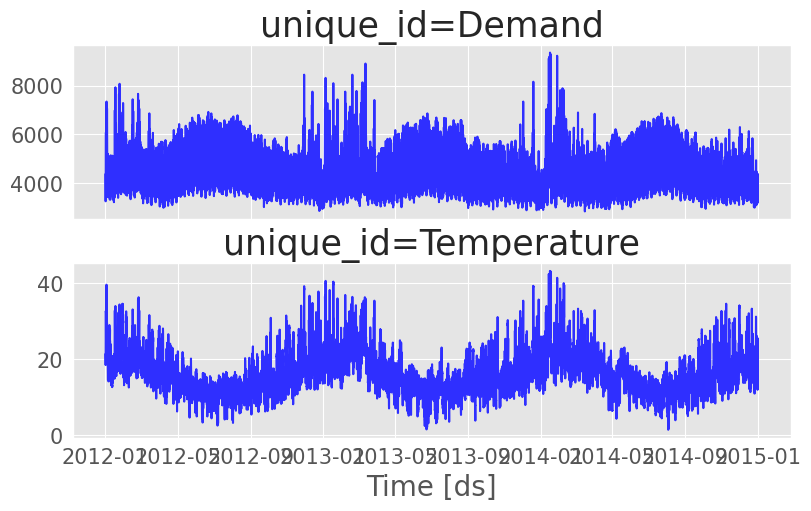

In [11]:
vic_elec = pd.read_csv(DATA_DIR / "vic_elec.csv", parse_dates=["ds"])
fig, axes = plt.subplots(2, 1, sharex=True)
plot_series(vic_elec, ylabel="", ax=axes)

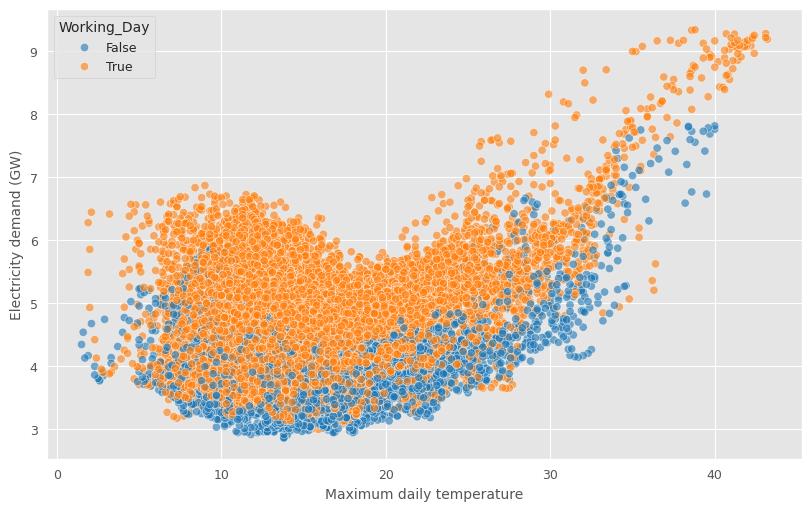

In [12]:
vic_elec_df = (
    vic_elec.loc[lambda x: x["ds"] >= "2014"]
    .pivot(index=["ds", "Holiday"], columns="unique_id", values="y")
    .reset_index().rename_axis(None, axis="columns")
    .assign(
        Demand=lambda x: x["Demand"] / 1e3,
        weekend=lambda x: x["ds"].dt.dayofweek.isin([5, 6]),
        Working_Day=lambda x: ~x["Holiday"] & ~x["weekend"],
        Cooling=lambda x: x["Temperature"].clip(lower=18),
        unique_id="VIC",
    )
    .drop(columns=["weekend", "Holiday"])
)

fig, ax = plt.subplots()
sns.scatterplot(data=vic_elec_df, x="Temperature", y="Demand",
    hue="Working_Day", palette="tab10", alpha=0.6, ax=ax)
ax.set(
    xlabel="Maximum daily temperature",
    ylabel="Electricity demand (GW)",
)
plt.show()

TypeError: plot_series() got an unexpected keyword argument 'legend_loc'

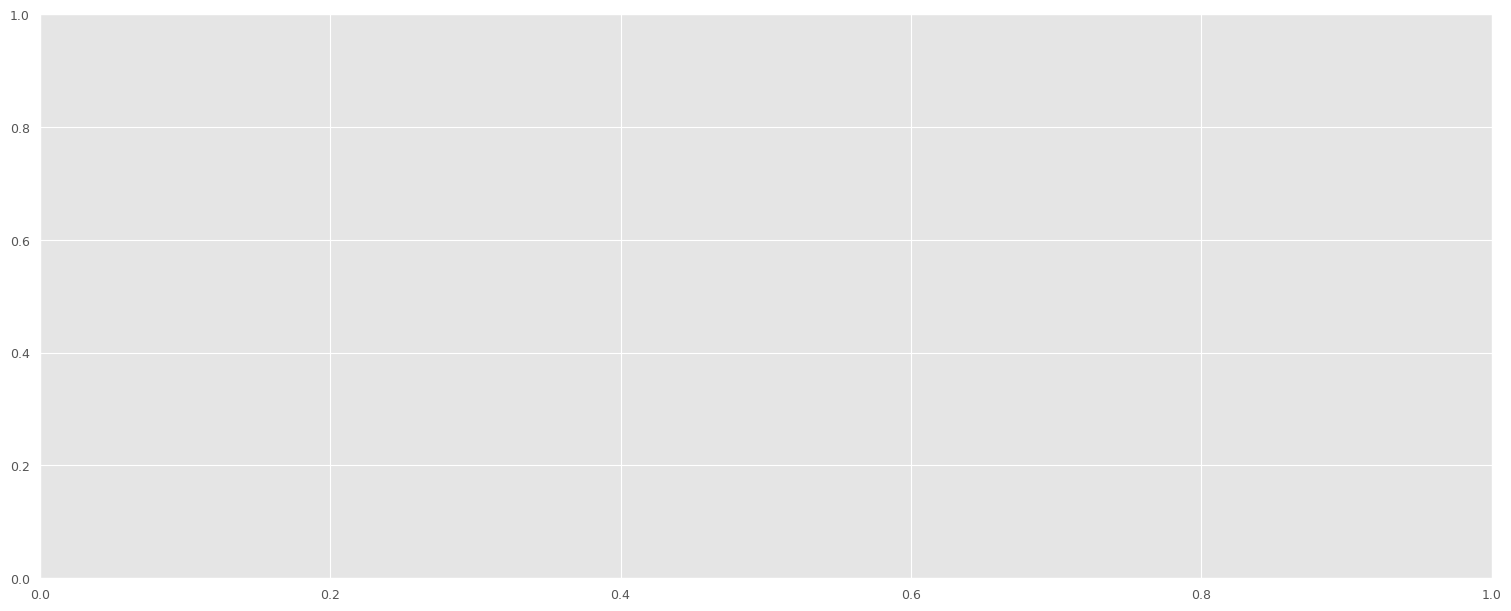

In [ ]:
features = [
    partial(fourier, season_length=2 * 24, k=10),
    partial(fourier, season_length=2 * 24 * 7, k=5),
    partial(fourier, season_length=2 * 24 * 7 * 365, k=3),
]
vic_elec_fourier, vic_elec_futr_fourier = pipeline(
    vic_elec_df, features=features, freq="30min", h=2 * 48)
model = AutoARIMA(max_d=0, seasonal=False, nmodels=20)
sf = StatsForecast(models=[model], freq="30min")
sf = sf.fit(vic_elec_fourier, target_col="Demand")

futr_df = (
    vic_elec_df.assign(ds=lambda x: x["ds"] + pd.to_timedelta("2d"))
    .drop(columns="Demand")
    .merge(vic_elec_futr_fourier)
)
level = [80, 95]
fc = sf.predict(h=len(futr_df), X_df=futr_df, level=level)



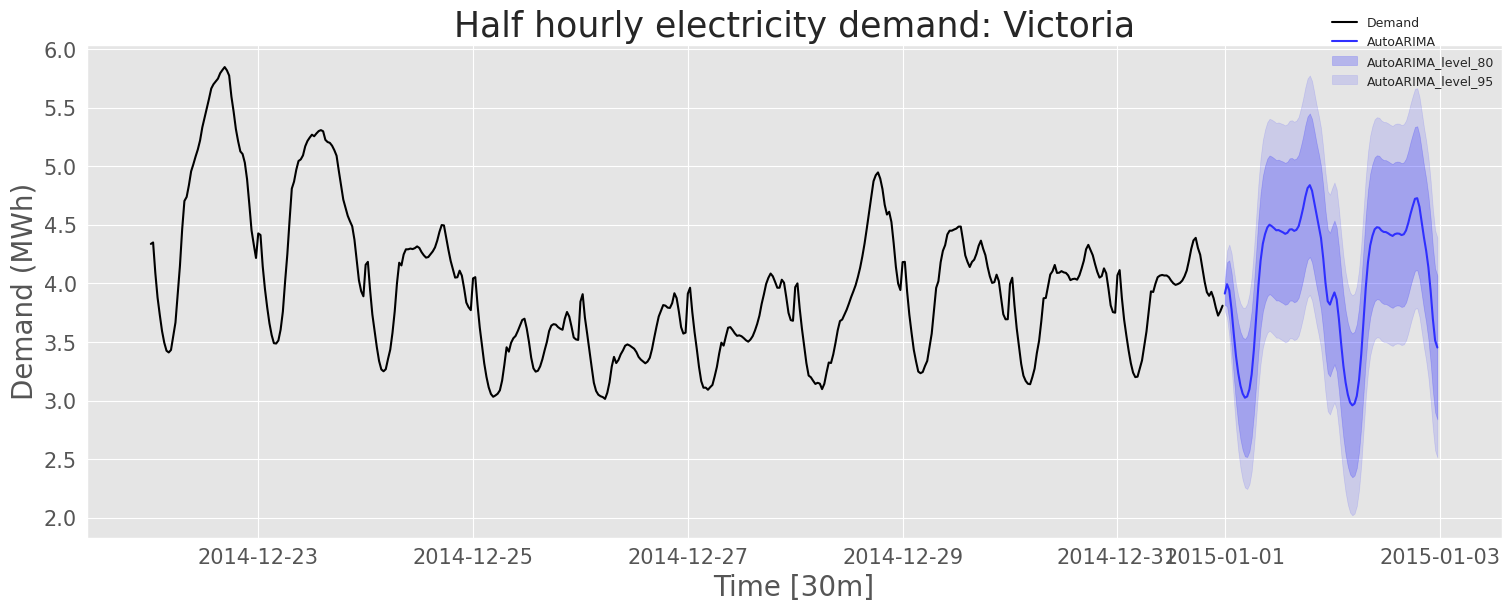

In [14]:
plot_series(
    vic_elec_fourier, fc, level=level, max_insample_length=10 * 48,
    target_col="Demand", xlabel="Time [30m]", ylabel="Demand (MWh)",
    title="Half hourly electricity demand: Victoria",
    palette="black_and_blue", rm_legend=False,)

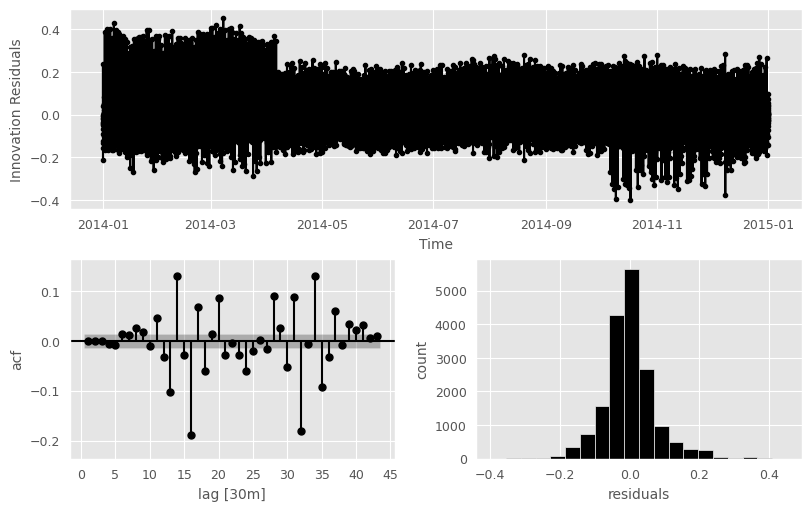

In [15]:
residuals = sf.fitted_[0, 0].model_["residuals"]
fig, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])
axes["resid"].plot(vic_elec_fourier["ds"], residuals, marker=".")
axes["resid"].set(xlabel="Time", ylabel="Innovation Residuals")
plot_acf(residuals, axes["acf"], zero=False, auto_ylims=True,
    bartlett_confint=False)
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["acf"].set(xlabel="lag [30m]", ylabel="acf", title="")
axes["hist"].hist(residuals, bins=20)
axes["hist"].set(xlabel="residuals", ylabel="count")
plt.show()

## 12.2 Prophet model 

Introduced by Facebook, Prophet is a nonlinear regression model originally designed for daily data featuring weekly and yearly seasonality, alongside holiday effects . It is structured as :$$y_t = g(t) + s(t) + h(t) + \varepsilon_t$$
Where:
* $g(t)$: A piecewise-linear trend (or "growth term") where changepoints are automatically selected .
* $s(t)$: Describes the various seasonal patterns modeled via Fourier terms (by default, order 10 for annual and order 3 for weekly seasonality) .
* $h(t)$: Holiday effects represented as simple dummy variables .
* $\varepsilon_t$: A white noise error term .
* The model is estimated using a Bayesian approach to allow for automatic selection of the changepoints and other model characteristics.

Example: Quarterly cement production

For this simple quarterly example, we will repeat the analysis from Section 9.10 in which we compared an ARIMA and ETS model, but we will add in a Prophet model for comparison. By default, Prophet fits weekly and yearly seasonalities. Since we have quarterly data, we need to specify this directly using add_seasonality.



20:57:52 - cmdstanpy - INFO - Chain [1] start processing


20:57:52 - cmdstanpy - INFO - Chain [1] done processing


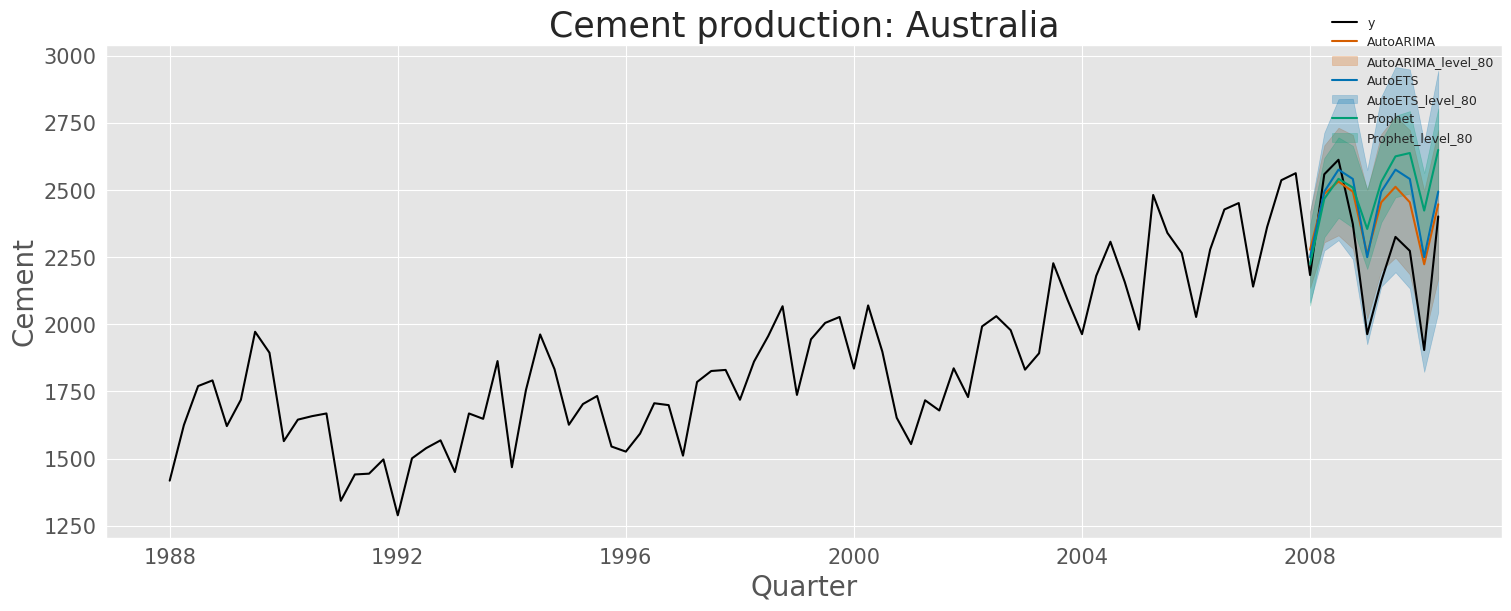

In [19]:
aus_production = pd.read_csv(DATA_DIR / "aus_production.csv",
    parse_dates=["ds"])
cement = (
    aus_production.loc[lambda x: x["ds"] >= "1988"]
    [["ds", "Cement"]]
    .rename(columns={"Cement": "y"})
    .assign(unique_id="Cement")
)
train = cement.loc[lambda x: x["ds"] < "2008"]
test = cement.loc[lambda x: x["ds"] >= "2008"]

m = Prophet(weekly_seasonality=False)
m.add_seasonality(name="quarterly", period=4, fourier_order=2)
m.fit(train)

future = m.make_future_dataframe(periods=10, freq="QS")
fc_prophet = (
    m.predict(future)[["ds", "yhat", "yhat_lower", "yhat_upper"]]
    .rename(columns={
        "yhat": "Prophet",
        "yhat_lower": "Prophet-lo-80",
        "yhat_upper": "Prophet-hi-80",
    })
)

models = [AutoARIMA(season_length=4), AutoETS(season_length=4)]
sf = StatsForecast(models=models, freq="QS")
level = [80]
fc_stats = sf.forecast(df=train, h=10, level=level)
fc = fc_stats.merge(fc_prophet, on="ds")

plot_series(cement, fc, level=level,
    xlabel="Quarter", ylabel="Cement",
    title="Cement production: Australia",
    palette="black_and_3color", rm_legend=False,
)

In [20]:
evaluation = (
    evaluate(
        fc.merge(test, on=["unique_id", "ds"]),
        metrics=[rmse, mae, mape, partial(mase, seasonality=4)],
        train_df=cement,
    )
    .drop(columns="unique_id")
    .sort_values("metric")
    .assign(metric=lambda x: x["metric"].str.upper())
    .set_index("metric").rename_axis("")
    .transpose()
    .rename_axis("Method").reset_index()
    .assign(MAPE=lambda x: 100 * x["MAPE"])
)
evaluation

,Method,MAE,MAPE,MASE,RMSE
0,AutoARIMA,169.078,7.868,1.124,195.204
1,AutoETS,191.152,8.862,1.271,222.180
2,Prophet,252.962,11.738,1.682,296.026


In this example, the Prophet forecasts are worse than either the ETS or ARIMA forecasts.

Example: Half-hourly electricity demand

We will now fit a prophet model to half-hourly electricity demand data, and compare its results with the MSTL model from the previous section.

21:02:01 - cmdstanpy - INFO - Chain [1] start processing
21:02:32 - cmdstanpy - INFO - Chain [1] done processing


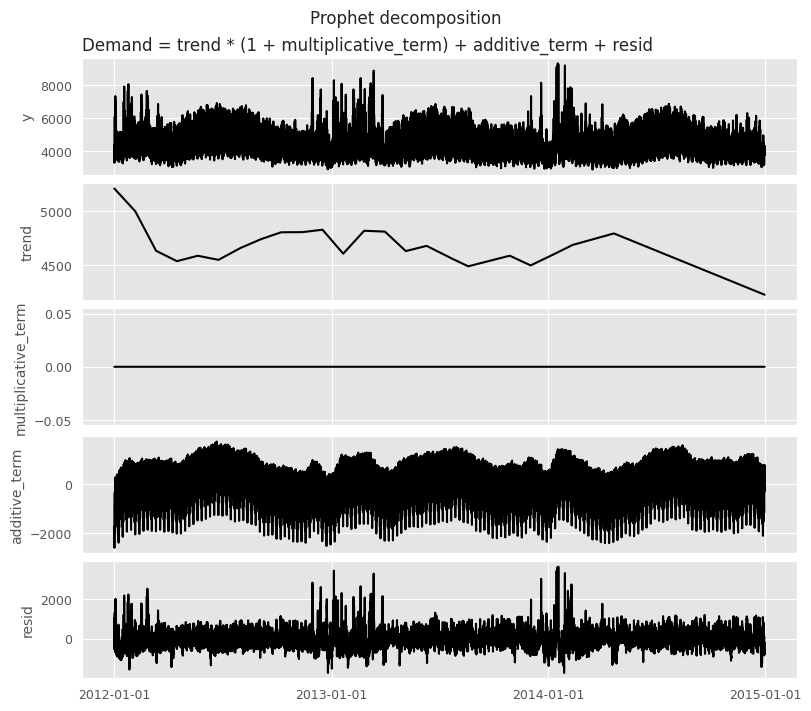

In [22]:
vic_demand = (
    vic_elec.loc[lambda x: x["unique_id"] == "Demand"]
    .drop(columns="Holiday")
    .rename(columns={"Demand": "y"})
    .assign(unique_id="VIC")
    [["unique_id", "ds", "y"]]
)
train = vic_demand.iloc[:-48]
test = vic_demand.iloc[-48:]

m = Prophet()
m.add_seasonality(name="hourly", period=48, fourier_order=5)
m.add_seasonality(name="subhourly", period=48 * 7, fourier_order=5)
m.fit(train)
future = m.make_future_dataframe(periods=48 * 2, freq="30min")
fc_prophet = (
    m.predict(future)
    .rename(columns={
        "yhat": "Prophet",
        "yhat_lower": "Prophet-lo-80",
        "yhat_upper": "Prophet-hi-80",
    })
    .assign(resid=lambda x: train["y"] - x["Prophet"])
)
renames = {
    "multiplicative_terms": "multiplicative_term",
    "additive_terms": "additive_term",
}
df = fc_prophet.merge(train[["ds", "y"]]).rename(columns=renames)
columns = ["y", "trend", "multiplicative_term", "additive_term", "resid"]

fig, axes = plt.subplots(5, sharex=True, figsize=(8, 7))
for (ax, column) in zip(axes, columns):
    sns.lineplot(data=df, x="ds", y=column, ax=ax, color="k")
axes[0].set_title(
  "Demand = trend * (1 + multiplicative_term) + additive_term + resid",
  loc="left")
axes[-1].set(xlabel="", xticks=["2012", "2013", "2014", "2015"])
fig.suptitle("Prophet decomposition")
plt.show()

The model specification is very similar to the DHR model in the previous section, although the result is different in several important ways. The Prophet model adds a piecewise linear time trend which is not really appropriate here as we don’t expect the long term forecasts to continue to follow the downward linear trend at the end of the series.

There is also substantial remaining autocorrelation in the residuals.

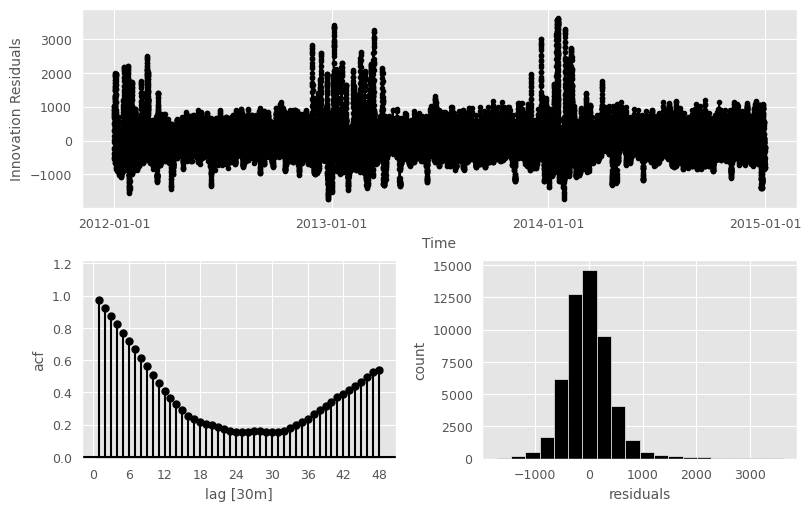

In [23]:
resid = fc_prophet[["ds", "resid"]].dropna()
fig, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])
axes["resid"].plot(resid["ds"], resid["resid"], marker=".")
axes["resid"].set(xlabel="Time", ylabel="Innovation Residuals",
    xticks=["2012", "2013", "2014", "2015"])
plot_acf(resid["resid"], axes["acf"], zero=False, auto_ylims=True,
    bartlett_confint=False)
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["acf"].set(xlabel="lag [30m]", ylabel="acf", title="")
axes["hist"].hist(resid["resid"], bins=20)
axes["hist"].set(xlabel="residuals", ylabel="count")
plt.show()

The prediction intervals would be narrower if the autocorrelations were taken into account. Now let’s compare these forecasts against MSTL.



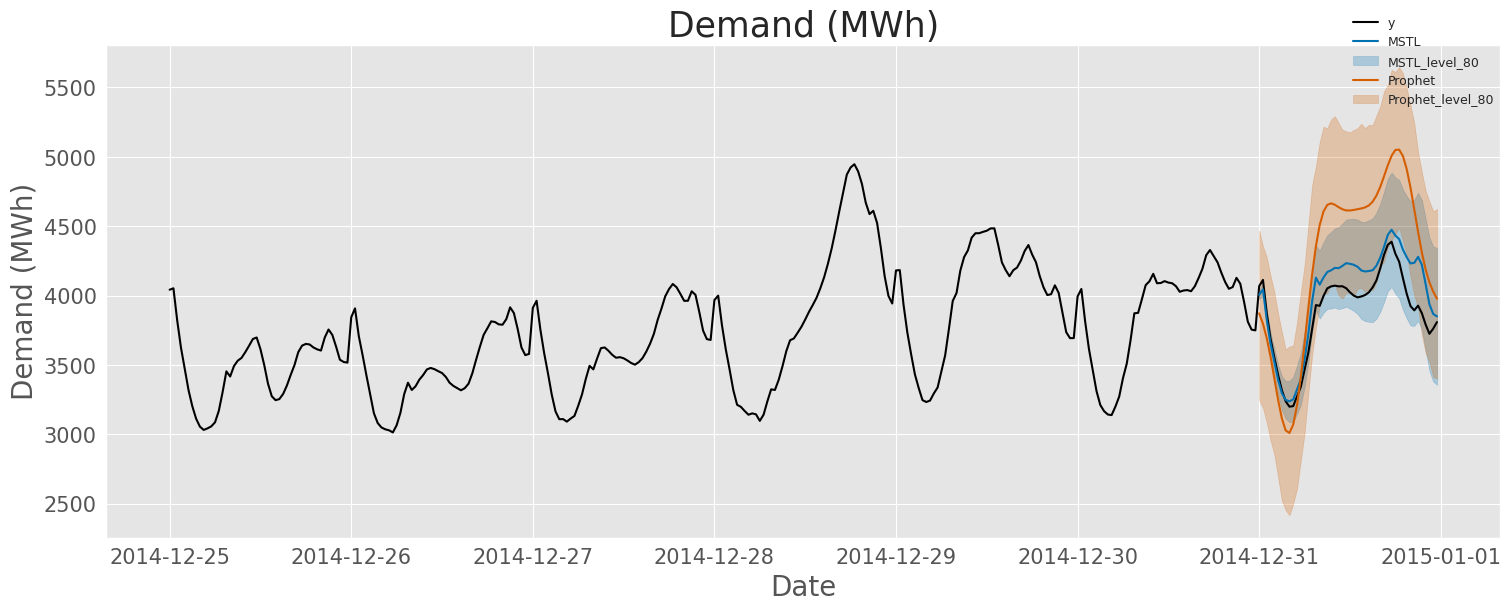

,Method,MAE,MAPE,MASE,RMSE
0,MSTL,138.730,3.529,0.364,165.452
1,Prophet,466.861,11.732,1.226,519.643


In [25]:
sf = StatsForecast(models=[MSTL(season_length=[48, 48 * 7])], freq="30min")
level = [80]
fc_stats = sf.forecast(df=train, h=48, level=level)

prophet_columns = ["ds", "Prophet", "Prophet-lo-80", "Prophet-hi-80"]
fc = fc_stats.merge(fc_prophet[prophet_columns], on="ds")

fig = plot_series(vic_demand, fc, level=level,
    max_insample_length=48 * 7,
    xlabel="Date", ylabel="Demand (MWh)", title = "Demand (MWh)",
    palette="black_and_2color", rm_legend=False,
)
display(fig)

evaluation = (
    evaluate(
        fc.merge(test, on=["unique_id", "ds"]),
        metrics=[rmse, mae, mape, partial(mase, seasonality=4)],
        train_df=train,
    )
    .drop(columns="unique_id")
    .sort_values("metric")
    .assign(metric=lambda x: x["metric"].str.upper())
    .set_index("metric").rename_axis("")
    .transpose()
    .rename_axis("Method").reset_index()
    .assign(MAPE=lambda x: 100 * x["MAPE"])
)
display(evaluation)

Prophet rarely gives better forecast accuracy than the alternative approaches, as these two examples have illustrated. However, it is a popular model for forecasting, with thousands of stars on GitHub and used as a dependency in hundreds of repositories. Its popularity can partly be explained by its open-source nature and ease of use. However, several studies, such as Garza et al. (2022) and Menculini et al. (2021), have shown that it does not perform well in terms of time and accuracy.

StatsForecast offers an adapter to Prophet with improved performance, as shown by Garza et al. (2022). It returns the best ARIMA model using Prophet’s feature preprocessing. To use it, simply replace Prophet with `AutoARIMAProphet`, as shown below using the previous example.

In [29]:
# m = AutoARIMAProphet()
# m.add_seasonality(name="hourly", period=48, fourier_order=5)
# m.add_seasonality(name="subhourly", period=48 * 7, fourier_order=5)
# m.fit(train)

# future = m.make_future_dataframe(periods=48 * 2, freq="30T")
# fc_ap = m.predict(future)

There is a more advanced model called `NeuralProphet` that combines neural networks with traditional time series algorithms and was inspired by Prophet. This model is available through PyPI and can be set up in a way similar to Prophet.

## 12.3 Vector autoregressions 

Univariate models assume a unidirectional relationship (predictors influence the forecast variable, but not vice versa) . Vector Autoregressions (VAR) address this limitation by allowing bi-directional feedback loops where all variables influence each other symmetrically (treating all variables as endogenous) .

For example, In previous chapters, the changes in personal consumption expenditure ($C_t$) were forecast based on the changes in personal disposable income ($I_t$). However, in this case a bi-directional relationship may be more suitable: an increase in $I_t$ will lead to an increase in $I_t$ and vice versa.

A 2-dimensional VAR model with 1 lag, or VAR(1), is expressed via a system of equations :$$\begin{aligned}
y_{1,t} &= c_1+\phi_{11,1}y_{1,t-1}+\phi_{12,1}y_{2,t-1}+\varepsilon_{1,t} \\
y_{2,t} &= c_2+\phi_{21,1}y_{1,t-1}+\phi_{22,1}y_{2,t-1}+\varepsilon_{2,t}
\end{aligned}$$
* where $\epsilon_{1,t}$ and $\epsilon_{2,t}$ are white noise processes that may be contemporaneously correlated. The coefficient $\phi_{ii,\ell}$ captures the influence of the ℓth lag of variable $y_i$ on itself, while the coefficient $\phi_{ij,\ell}$ captures the influence of the ℓth lag of variable $y_j$ and $y_i$.

* Estimation: Models are estimated equation-by-equation via the principle of least squares .
    * If the series are stationary, it is a VAR in levels .
    * If the series are non-stationary, they are differenced first, resulting in a VAR in differences .

* Lags and Variables: The number of parameters grows rapidly as $K + pK^2$ (where $K$ is the number of variables and $p$ is the lag order) . Because large models introduce high estimation errors, $K$ is usually kept small . Forecasters typically rely on the Bayesian Information Criterion (BIC) over $AICc$ to select lags, as BIC penalizes parameters more heavily and avoids over-fitting .

## 12.4 Bootstrapping and bagging 

These techniques leverage resampling to improve uncertainty estimation and forecast accuracy .

### Bootstrapping Time Series
To simulate realistic alternative versions of a historical time series, the original series is decomposed via STL into trend, seasonal, and remainder components .
* Because time series residuals often contain autocorrelation, a simple random draw does not work.
* Instead, a blocked bootstrap is used, where contiguous blocks of time series residuals are randomly selected and shuffled together to preserve local dependency structures . These shuffled remainders are recombined with the trend and seasonal components to yield variations of the data .

### Bagged Forecasts (Bootstrap Aggregating)
Bagging uses these bootstrapped series to boost overall accuracy .
* Simulate: Generate a large number of alternative time series (e.g., 100 series) using the blocked bootstrap method .
* Model: Fit an ensemble model (like AutoETS) to each simulated series individually . Each model configuration and parameter set will be slightly unique .
* Aggregate: Average the resulting forecasts for each time horizon to generate the final "bagged forecast" .
* While bagging requires significantly more computation time, studies (such as Bergmeir et al., 2016) show that it consistently produces superior, more robust forecasts on average compared to applying a single model directly to the raw data .